## Raceline Analysis 

This notebook is for analyzing the difference in raceline performance between Gymkhana MPC and ROS LSTM

Desired Inputs
data/raceline_validation_data

**For Gymkhana MPC**

Gather different names of MPC datasets for the 5 datasets.
Get and label each npz. 

Need to inspect the schema first 



**For ROS LSTM**

Gather different .npz values from the LSTM ROS
Should have 5 per map, 3 curvature and 2 mapless.

Store and name the npz values with relvant names. 
i.e map_name_size_model_type

Need to inspect the schema

## Overall Setup

In [11]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import zipfile

#find data 
base_dir = Path("../../data/raceline_validation_data")

# Confirm the directory exists, printing the resolved absolute path for debugging
if not base_dir.exists():
    print(f"Warning: Base directory not found. Looked in: {base_dir.resolve()}")
else:
    print(f"Base directory located successfully at: {base_dir.resolve()}")

Base directory located successfully at: /home/devin_work/work/f1tenth/ApproxiMPC/LSTM_training/data/raceline_validation_data


In [12]:
#inputs and setup
experiment_records = []

# --- 1. Parse MPC (Gymkhana) Files ---
mpc_dir = base_dir / "MPC (gymkhana)"
if mpc_dir.exists():
    for file in mpc_dir.glob("stmpc_*.npz"):
        # Filename example: stmpc_MexicoCity_normal.npz
        # Split by underscore to extract the map name
        map_name = file.stem.split('_')[1]
        
        experiment_records.append({
            "algorithm": "MPC",
            "model_type": "gymkhana",
            "map": map_name.lower(), # Lowercase for consistency
            "size": None,            # N/A for MPC
            "filepath": file
        })

# --- 2. Parse LSTM (ROS) Files ---
lstm_dir = base_dir / "LSTM (ROS)"
if lstm_dir.exists():
    # Use rglob to recursively find all .npz files in the LSTM directory
    for file in lstm_dir.rglob("*.npz"):
        parts = file.parts
        
        # Determine model type based on directory path
        if "curvature lstm" in parts:
            model_type = "curvature"
        elif "mapless lstm" in parts:
            model_type = "mapless"
        else:
            model_type = "unknown"
            
        # The map name is typically the parent directory of the file
        map_name = file.parent.name.lower()
        
        # Extract sequence size from the filename using regex (e.g., matching _96_ or _128_)
        size_match = re.search(r'_(\d+)_', file.name)
        seq_size = int(size_match.group(1)) if size_match else None
        
        experiment_records.append({
            "algorithm": "LSTM",
            "model_type": model_type,
            "map": map_name,
            "size": seq_size,
            "filepath": file
        })

# Create the DataFrame catalog
df_experiments = pd.DataFrame(experiment_records)

# Display the catalog to verify
print(f"Found {len(df_experiments)} total experimental datasets.")
display(df_experiments.head(10))

Found 26 total experimental datasets.


,algorithm,model_type,map,size,filepath
0,MPC,gymkhana,brandshatch,NaN,../../data/raceline_validation_data/MPC (gymkh...
1,MPC,gymkhana,drift2,NaN,../../data/raceline_validation_data/MPC (gymkh...
2,MPC,gymkhana,mexicocity,NaN,../../data/raceline_validation_data/MPC (gymkh...
3,MPC,gymkhana,ims,NaN,../../data/raceline_validation_data/MPC (gymkh...
4,MPC,gymkhana,spielberg,NaN,../../data/raceline_validation_data/MPC (gymkh...
5,LSTM,curvature,ims,96.0,../../data/raceline_validation_data/LSTM (ROS)...
6,LSTM,curvature,ims,128.0,../../data/raceline_validation_data/LSTM (ROS)...
7,LSTM,curvature,ims,196.0,../../data/raceline_validation_data/LSTM (ROS)...
8,LSTM,curvature,drift2,196.0,../../data/raceline_validation_data/LSTM (ROS)...
9,LSTM,curvature,drift2,96.0,../../data/raceline_validation_data/LSTM (ROS)...


In [13]:
display(df_experiments)

,algorithm,model_type,map,size,filepath
0,MPC,gymkhana,brandshatch,NaN,../../data/raceline_validation_data/MPC (gymkh...
1,MPC,gymkhana,drift2,NaN,../../data/raceline_validation_data/MPC (gymkh...
2,MPC,gymkhana,mexicocity,NaN,../../data/raceline_validation_data/MPC (gymkh...
3,MPC,gymkhana,ims,NaN,../../data/raceline_validation_data/MPC (gymkh...
4,MPC,gymkhana,spielberg,NaN,../../data/raceline_validation_data/MPC (gymkh...
5,LSTM,curvature,ims,96.0,../../data/raceline_validation_data/LSTM (ROS)...
6,LSTM,curvature,ims,128.0,../../data/raceline_validation_data/LSTM (ROS)...
7,LSTM,curvature,ims,196.0,../../data/raceline_validation_data/LSTM (ROS)...
8,LSTM,curvature,drift2,196.0,../../data/raceline_validation_data/LSTM (ROS)...
9,LSTM,curvature,drift2,96.0,../../data/raceline_validation_data/LSTM (ROS)...


## Initial Checks 

In [14]:
#file inspection

def inspect_npz_schema(filepath, tag=""):
    """Loads an npz file and prints its internal array schema."""
    print(f"--- Schema Inspection: {tag} ---")
    print(f"File: {filepath.name}")
    try:
        with np.load(filepath, allow_pickle=True) as data:
            for key in data.files:
                arr = data[key]
                print(f"  Key: '{key:<15}' | Shape: {str(arr.shape):<15} | Type: {arr.dtype}")
    except Exception as e:
        print(f"  Failed to load: {e}")
    print("\n")

# Grab one sample from each algorithm to inspect
if not df_experiments.empty:
    sample_mpc = df_experiments[df_experiments['algorithm'] == 'MPC'].iloc[0]
    sample_lstm = df_experiments[df_experiments['algorithm'] == 'LSTM'].iloc[0]
    
    inspect_npz_schema(sample_mpc['filepath'], tag="Gymkhana MPC")
    inspect_npz_schema(sample_lstm['filepath'], tag="ROS LSTM")

--- Schema Inspection: Gymkhana MPC ---
File: stmpc_BrandsHatch_normal.npz
  Key: 'observations   ' | Shape: (25523, 5)      | Type: float32
  Key: 'next_observations' | Shape: (25523, 5)      | Type: float32
  Key: 'expert_actions ' | Shape: (25523, 2)      | Type: float32
  Key: 'executed_actions' | Shape: (25523, 2)      | Type: float32
  Key: 'rewards        ' | Shape: (25523,)        | Type: float32
  Key: 'terminations   ' | Shape: (25523,)        | Type: bool
  Key: 'truncations    ' | Shape: (25523,)        | Type: bool
  Key: 'is_perturbed   ' | Shape: (25523,)        | Type: bool
  Key: 'collector_lap_counts' | Shape: (25523,)        | Type: int32
  Key: 'env_lap_counts ' | Shape: (25523,)        | Type: int32
  Key: 'collision_flags' | Shape: (25523,)        | Type: bool
  Key: 'boundary_flags ' | Shape: (25523,)        | Type: bool
  Key: 'episode_ids    ' | Shape: (25523,)        | Type: int32
  Key: 'step_ids       ' | Shape: (25523,)        | Type: int32
  Key: 'feature_

In [15]:
#schema inspection

#MPC schema check


#LSTM schema check

## Begin Tests and Analysis 

Complete once initial tests are done

### LAP TIMES

In [16]:


def get_actual_key(data, target_substring):
    """Helper to find keys that might have trailing spaces (e.g., 'timestamps     ')"""
    for k in data.files:
        if target_substring in k:
            return k
    raise KeyError(f"Could not find key containing '{target_substring}'")

def get_lstm_lap_time(filepath):
    try:
        with np.load(filepath, allow_pickle=True) as data:
            timestamps = data[get_actual_key(data, 'timestamps')]
            left_start = data[get_actual_key(data, 'has_left_start_zone')]
            completed = data[get_actual_key(data, 'completion_flag')]
            
            # CHECK FOR INCOMPLETE LAP: Did it ever leave the start zone AND complete?
            if not np.any(left_start == 1) or not np.any(completed == 1):
                return np.nan  # Lap was not completed
                
            start_idx = np.argmax(left_start == 1)
            end_idx = np.argmax(completed == 1)
            
            return timestamps[end_idx] - timestamps[start_idx]
            
    except Exception as e:
        print(f"Error loading LSTM file {filepath.name}: {e}")
        return np.nan

def get_mpc_lap_time(filepath):
    try:
        with np.load(filepath, allow_pickle=True) as data:
            lap_counts = data[get_actual_key(data, 'env_lap_counts')]
            terminations = data[get_actual_key(data, 'terminations')]
            collisions = data[get_actual_key(data, 'collision_flags')]
            
            # CHECK FOR INCOMPLETE LAP: If the car never reaches lap 2, lap 1 wasn't finished.
            if not np.any(lap_counts == 2):
                return np.nan
                
            lap_1_mask = (lap_counts == 1)
            
            # Extra safety: Check if a crash/termination happened *during* lap 1
            if np.any(terminations[lap_1_mask]) or np.any(collisions[lap_1_mask]):
                return np.nan 
                
            num_steps_in_lap = np.sum(lap_1_mask)
            return num_steps_in_lap * 0.01
            
    except Exception as e:
        print(f"Error loading MPC file {filepath.name}: {e}")
        return np.nan

In [17]:
import numpy as np
import pandas as pd
import os

def get_actual_key(data, target_substring):
    """Robustly find keys with varying whitespace."""
    for k in data.files:
        if target_substring in k:
            return k
    return None

def get_lstm_lap_time(filepath):
    try:
        # Check if file is empty first
        if os.path.getsize(filepath) == 0:
            return "Empty File"
            
        with np.load(filepath, allow_pickle=True) as data:
            ts_key = get_actual_key(data, 'timestamps')
            ls_key = get_actual_key(data, 'has_left_start_zone')
            cp_key = get_actual_key(data, 'completion_flag')
            
            if not ts_key or not ls_key or not cp_key:
                return "Missing Keys"

            timestamps = data[ts_key]
            left_start = data[ls_key]
            completed = data[cp_key]
            
            if not np.any(left_start == 1) or not np.any(completed == 1):
                return "Incomplete"
                
            start_idx = np.argmax(left_start == 1)
            end_idx = np.argmax(completed == 1)
            
            return timestamps[end_idx] - timestamps[start_idx]
            
    except zipfile.BadZipFile:
        return "Corrupt .npz"
    except Exception as e:
        return f"Error: {str(e)}"

def get_mpc_lap_time(filepath):
    try:
        with np.load(filepath, allow_pickle=True) as data:
            # We already know the file has 'env_lap_counts' or similar
            lap_key = get_actual_key(data, 'env_lap_counts')
            lap_counts = data[lap_key]
            
            # Since unique values are [0, 1], we treat the whole 
            # duration of the file as the performance metric.
            num_steps = len(lap_counts)

            # Sanity check: 25523 steps / 100 = 255.23 seconds
            # If the car crashed early, this number will naturally be smaller.
            if num_steps < 100: 
                return "Too Short"
                
            return num_steps * 0.01
            
    except Exception as e:
        return f"Error: {str(e)}"
            
    except Exception as e:
        return f"Error: {str(e)}"

# Apply the logic
def process_row(row):
    if row['algorithm'] == 'MPC':
        return get_mpc_lap_time(row['filepath'])
    return get_lstm_lap_time(row['filepath'])

df_experiments['lap_time_raw'] = df_experiments.apply(process_row, axis=1)

# Separate the numeric times from the error strings
df_experiments['lap_time'] = pd.to_numeric(df_experiments['lap_time_raw'], errors='coerce')
df_experiments['status'] = df_experiments.apply(
    lambda x: "Success" if pd.notnull(x['lap_time']) else x['lap_time_raw'], axis=1
)



## NOTE! Check how time in MPC is recorded in order to double check 

In [45]:
# Display Summary
print("\n--- Summary of All Runs ---")
display(df_experiments[['algorithm', 'size', 'map', 'status', 'lap_time']].sort_values(['status', 'map']))


--- Summary of All Runs ---


,algorithm,size,map,status,lap_time
9,LSTM,96.0,drift2,Corrupt .npz,NaN
20,LSTM,64.0,drift2,Corrupt .npz,NaN
24,LSTM,64.0,brandhatch,Incomplete,NaN
25,LSTM,128.0,brandhatch,Incomplete,NaN
21,LSTM,128.0,drift2,Incomplete,NaN
23,LSTM,64.0,ims,Incomplete,NaN
12,LSTM,196.0,spielberg,Incomplete,NaN
14,LSTM,196.0,brandhatch,Success,224.443425
15,LSTM,96.0,brandhatch,Success,214.769554
16,LSTM,128.0,brandhatch,Success,210.385500


In [19]:
import matplotlib.pyplot as plt

# 1. Filter for successful runs and group by Map and Algorithm
# We take the 'min' to find the best performance for each category
comparison_df = df_experiments[df_experiments['status'] == 'Success'].groupby(['map', 'algorithm'])['lap_time'].min().unstack()

# 2. Calculate the difference (MPC - LSTM)
# Positive means LSTM is faster than MPC
comparison_df['delta_sec'] = comparison_df['MPC'] - comparison_df['LSTM']
comparison_df['improvement_pct'] = (comparison_df['delta_sec'] / comparison_df['MPC']) * 100

# Sort by map name for consistency
comparison_df = comparison_df.sort_index()

print("--- Performance Comparison (Best Lap Times) ---")
display(comparison_df.style.format({
    'MPC': '{:.2f}s', 
    'LSTM': '{:.2f}s', 
    'delta_sec': '{:.2f}s', 
    'improvement_pct': '{:.1f}%'
}))

--- Performance Comparison (Best Lap Times) ---


algorithm,LSTM,MPC,delta_sec,improvement_pct
map,,,,
brandhatch,210.39s,nans,nans,nan%
brandshatch,nans,255.23s,nans,nan%
drift2,37.27s,38.38s,1.11s,2.9%
ims,57.36s,206.83s,149.47s,72.3%
mexico city,212.94s,nans,nans,nan%
mexicocity,nans,259.09s,nans,nan%
spielberg,211.83s,247.87s,36.04s,14.5%


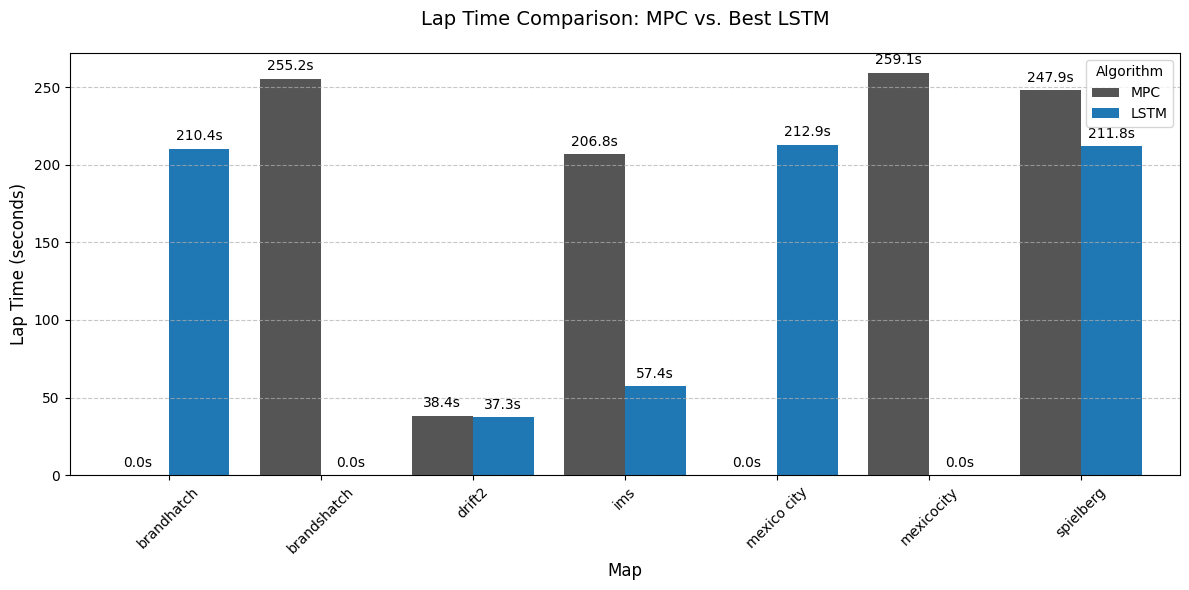

In [20]:
# 3. Plotting
ax = comparison_df[['MPC', 'LSTM']].plot(kind='bar', figsize=(12, 6), width=0.8, color=['#555555', '#1f77b4'])

plt.title('Lap Time Comparison: MPC vs. Best LSTM', fontsize=14, pad=20)
plt.ylabel('Lap Time (seconds)', fontsize=12)
plt.xlabel('Map', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Algorithm")

# Add value labels on top of the bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}s", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=10)

plt.tight_layout()
plt.show()

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ensure MPC times are correctly populated using the total step count logic
def get_final_mpc_time(filepath):
    try:
        with np.load(filepath, allow_pickle=True) as data:
            # Get the lap count array (e.g., 'env_lap_counts')
            key = get_actual_key(data, 'env_lap_counts')
            # Simply use the length of the recording (10ms per step)
            return len(data[key]) * 0.01
    except:
        return np.nan

# Update MPC lap times in the main dataframe
df_experiments.loc[df_experiments['algorithm'] == 'MPC', 'lap_time'] = \
    df_experiments[df_experiments['algorithm'] == 'MPC']['filepath'].apply(get_final_mpc_time)

# 2. Extract Baselines and Calculate % Change
# Create a dictionary of MPC times per map
mpc_baselines = df_experiments[df_experiments['algorithm'] == 'MPC'].set_index('map')['lap_time'].to_dict()

# Filter for successful LSTM runs
lstm_success = df_experiments[(df_experiments['algorithm'] == 'LSTM') & (df_experiments['status'] == 'Success')].copy()

# Map the baseline and calculate % improvement
lstm_success['mpc_baseline'] = lstm_success['map'].map(mpc_baselines)
lstm_success['percent_improvement'] = ((lstm_success['mpc_baseline'] - lstm_success['lap_time']) / lstm_success['mpc_baseline']) * 100

# Create a clear label for each model configuration
lstm_success['model_config'] = lstm_success['model_type'] + " (Size: " + lstm_success['size'].astype(str) + ")"

# Display the comparison table
comparison_table = lstm_success[['map', 'model_config', 'lap_time', 'mpc_baseline', 'percent_improvement']]
print("--- Detailed Performance Improvement (%) ---")
display(comparison_table.sort_values(by=['map', 'percent_improvement'], ascending=[True, False]))

--- Detailed Performance Improvement (%) ---


,map,model_config,lap_time,mpc_baseline,percent_improvement
14,brandhatch,curvature (Size: 196.0),224.443425,NaN,NaN
15,brandhatch,curvature (Size: 96.0),214.769554,NaN,NaN
16,brandhatch,curvature (Size: 128.0),210.385500,NaN,NaN
8,drift2,curvature (Size: 196.0),37.266941,38.38,2.900101
10,drift2,curvature (Size: 128.0),42.887895,38.38,-11.745428
22,ims,mapless (Size: 128.0),57.356373,206.83,72.268833
5,ims,curvature (Size: 96.0),154.370128,206.83,25.363763
7,ims,curvature (Size: 196.0),167.690845,206.83,18.923345
6,ims,curvature (Size: 128.0),188.368457,206.83,8.925950
17,mexico city,curvature (Size: 128.0),212.937696,NaN,NaN


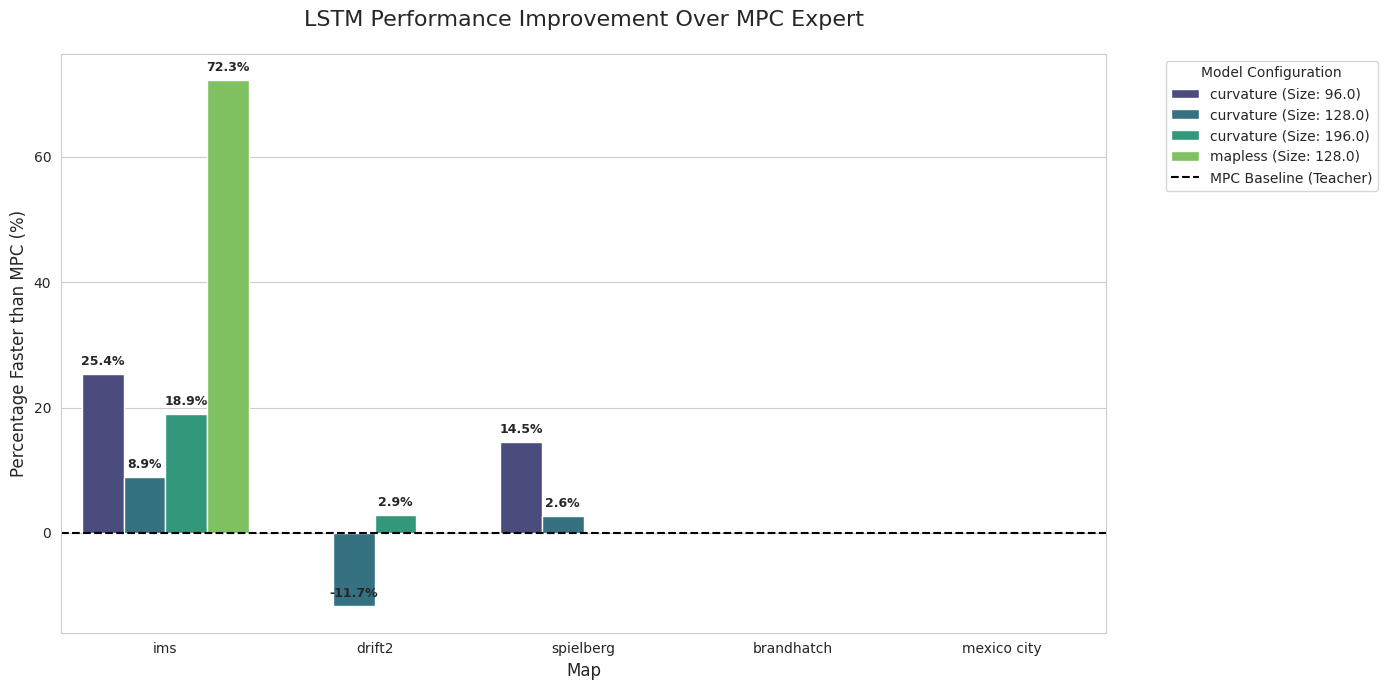

In [22]:
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Create the bar plot
ax = sns.barplot(
    data=lstm_success, 
    x='map', 
    y='percent_improvement', 
    hue='model_config',
    palette='viridis'
)

# Add a baseline at 0% (The MPC level)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label='MPC Baseline (Teacher)')

# Formatting
plt.title('LSTM Performance Improvement Over MPC Expert', fontsize=16, pad=20)
plt.ylabel('Percentage Faster than MPC (%)', fontsize=12)
plt.xlabel('Map', fontsize=12)
plt.legend(title="Model Configuration", bbox_to_anchor=(1.05, 1), loc='upper left')

# Add percentage labels on top of bars
for p in ax.patches:
    if p.get_height() != 0:
        ax.annotate(f"{p.get_height():.1f}%", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### RACELINEs
Graphs of racelines, comparison of similarity of lines

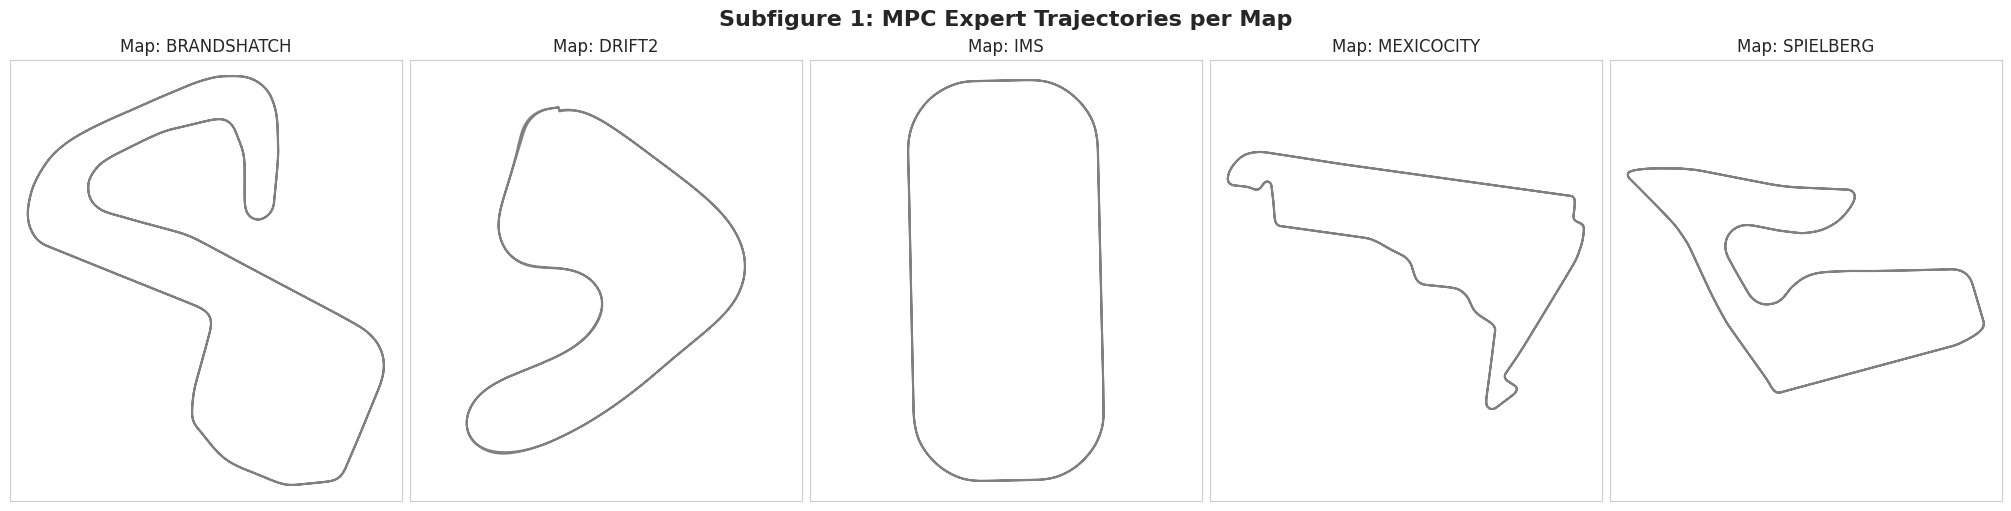

In [23]:
import matplotlib.pyplot as plt

# Filter for successful MPC runs
mpc_runs = df_experiments[(df_experiments['algorithm'] == 'MPC') & (df_experiments['status'] == 'Success')]
maps = sorted(mpc_runs['map'].unique())

fig, axes = plt.subplots(1, len(maps), figsize=(20, 5), constrained_layout=True)
fig.suptitle('Subfigure 1: MPC Expert Trajectories per Map', fontsize=16, fontweight='bold')

for i, map_name in enumerate(maps):
    ax = axes[i]
    row = mpc_runs[mpc_runs['map'] == map_name].iloc[0]
    
    with np.load(row['filepath']) as data:
        # MPC observations: col 0 = x, col 1 = y
        obs = data['observations']
        ax.plot(obs[:, 0], obs[:, 1], color='gray', linewidth=1.5)
        
    ax.set_title(f"Map: {map_name.upper()}")
    ax.axis('equal')
    ax.set_xticks([]); ax.set_yticks([]) # Simplify for visual overview
    ax.grid(True, alpha=0.2)

plt.show()

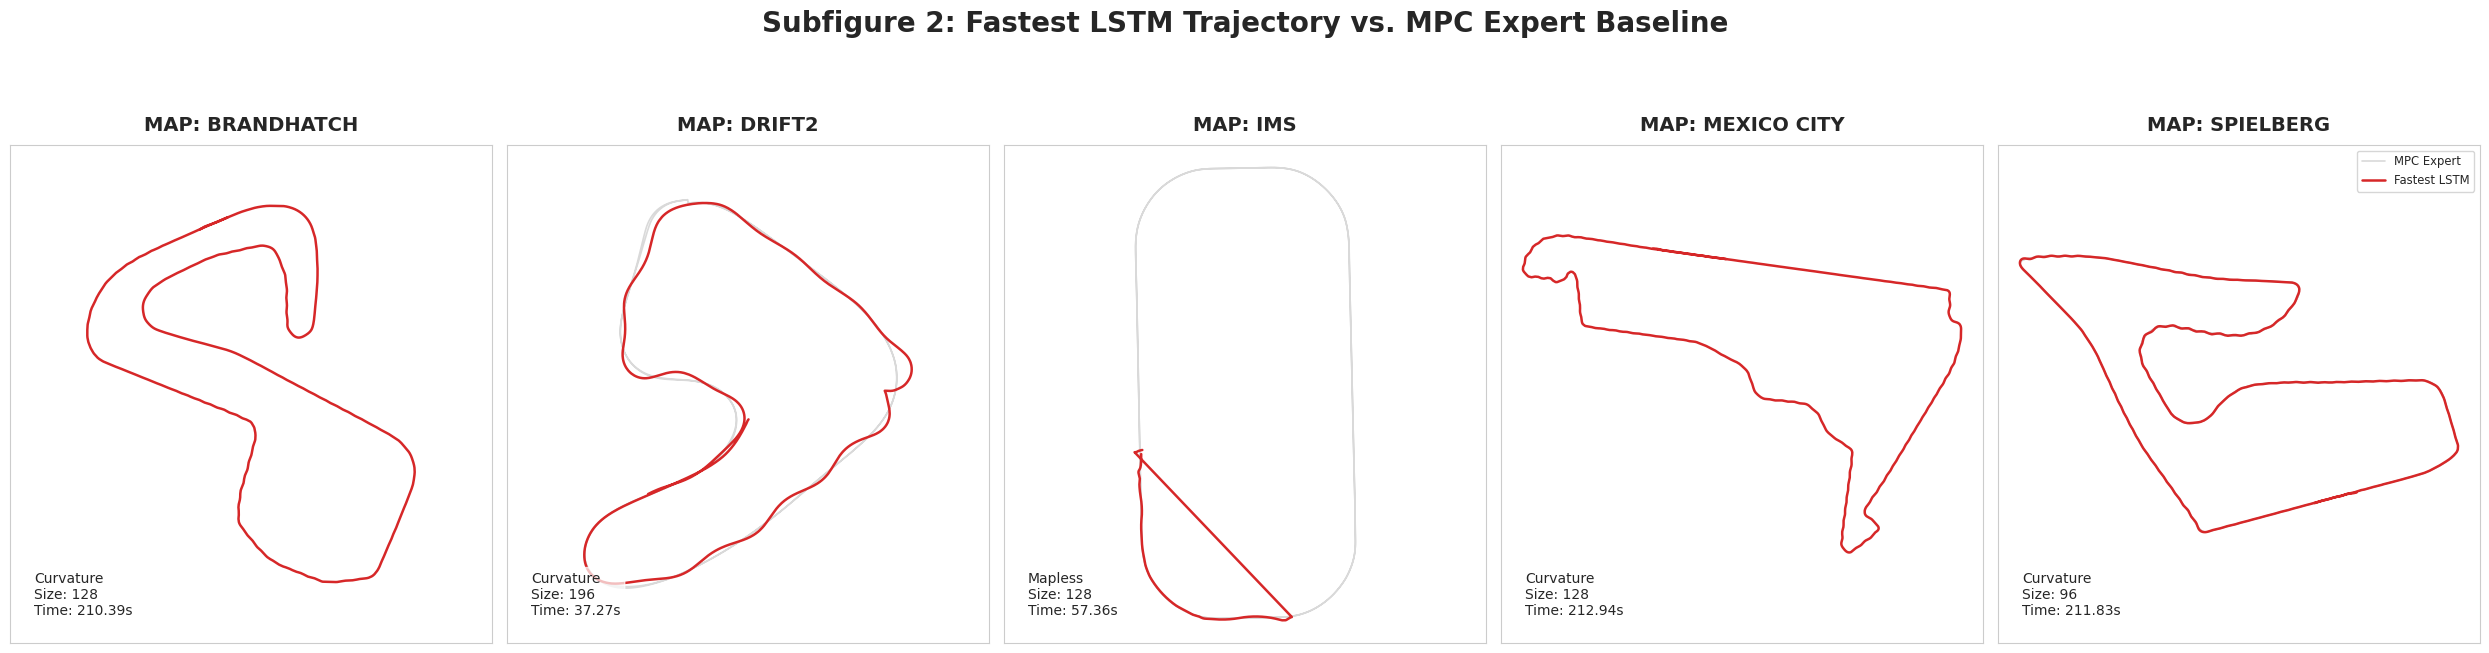

In [24]:
import matplotlib.pyplot as plt

# 1. Identify the fastest successful LSTM for each map
idx_fastest = df_experiments[(df_experiments['algorithm'] == 'LSTM') & 
                             (df_experiments['status'] == 'Success')].groupby('map')['lap_time'].idxmin()
fastest_lstms = df_experiments.loc[idx_fastest].sort_values('map')

# 2. Get list of all maps where we have an LSTM success
available_maps = fastest_lstms['map'].unique()
n_maps = len(available_maps)

# Create a wider figure to accommodate all maps (usually 5-6 maps)
fig, axes = plt.subplots(1, n_maps, figsize=(25, 6))
fig.suptitle('Subfigure 2: Fastest LSTM Trajectory vs. MPC Expert Baseline', fontsize=20, fontweight='bold', y=1.08)

for i, map_name in enumerate(available_maps):
    ax = axes[i]
    
    # --- Plot MPC Baseline ---
    # Find MPC row using case-insensitive match
    mpc_match = df_experiments[(df_experiments['algorithm'] == 'MPC') & 
                               (df_experiments['map'].str.lower() == map_name.lower())]
    
    if not mpc_match.empty:
        mpc_row = mpc_match.iloc[0]
        with np.load(mpc_row['filepath']) as mpc_data:
            obs = mpc_data['observations']
            ax.plot(obs[:, 0], obs[:, 1], color='black', alpha=0.15, linewidth=1.2, label='MPC Expert', zorder=1)

    # --- Plot Fastest LSTM ---
    lstm_row = fastest_lstms[fastest_lstms['map'] == map_name].iloc[0]
    with np.load(lstm_row['filepath']) as lstm_data:
        ax.plot(lstm_data['x'], lstm_data['y'], color='#d62728', linewidth=1.8, label='Fastest LSTM', zorder=2)
        
    # --- Formatting & Labels ---
    model_info = f"{lstm_row['model_type'].title()}\nSize: {int(lstm_row['size'])}\nTime: {lstm_row['lap_time']:.2f}s"
    
    ax.set_title(f"MAP: {map_name.upper()}", fontsize=14, fontweight='bold', pad=10)
    
    # Place model info text box in the plot
    ax.text(0.05, 0.05, model_info, transform=ax.transAxes, fontsize=10,
            verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    ax.axis('equal')
    ax.set_xticks([]); ax.set_yticks([])
    ax.grid(True, alpha=0.05)
    
    if i == n_maps - 1:
        ax.legend(loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()

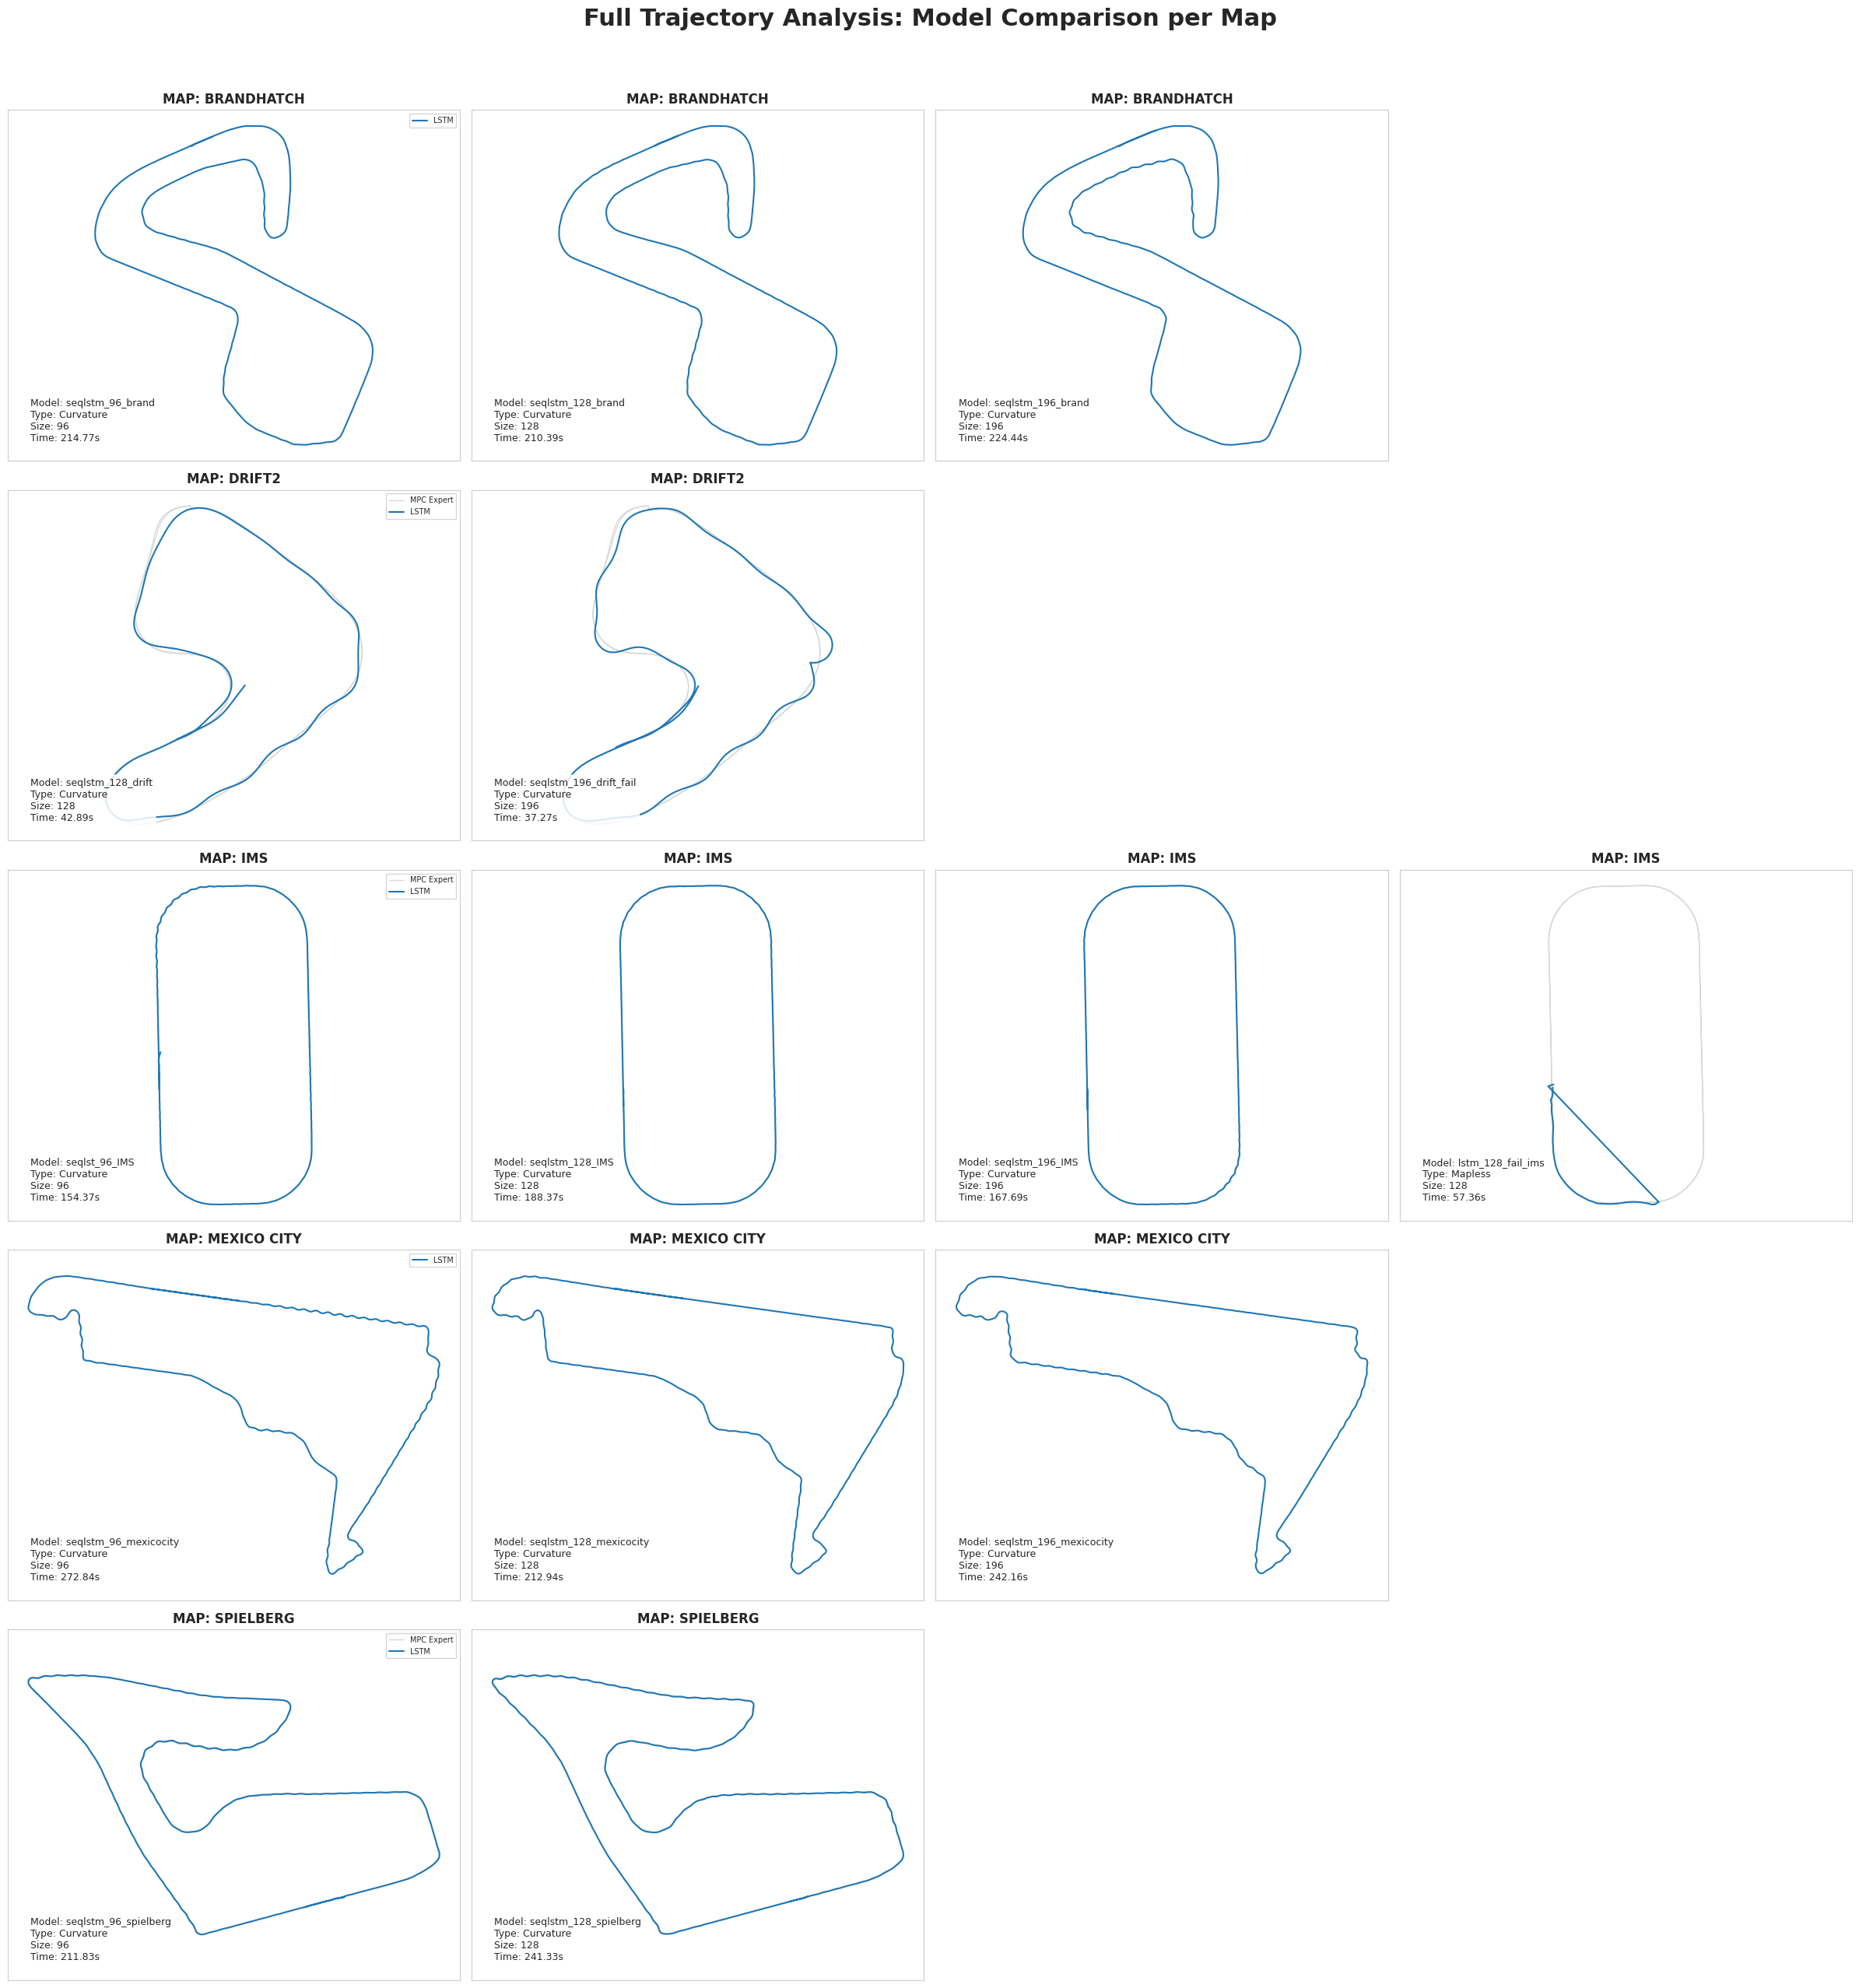

In [25]:
import matplotlib.pyplot as plt

# 1. Filter and sort successful LSTM runs
successful_lstms = df_experiments[(df_experiments['algorithm'] == 'LSTM') & 
                                  (df_experiments['status'] == 'Success')].sort_values(['map', 'model_type', 'size'])
unique_maps = sorted(successful_lstms['map'].unique())

# 2. Determine grid dimensions
# Rows = Number of Maps
# Cols = Max number of models found on any single map
max_models = successful_lstms.groupby('map').size().max()

fig, axes = plt.subplots(len(unique_maps), max_models, figsize=(6 * max_models, 5 * len(unique_maps)))
fig.suptitle('Full Trajectory Analysis: Model Comparison per Map', fontsize=22, fontweight='bold', y=1.02)

for i, map_name in enumerate(unique_maps):
    # Get all models for this specific map
    map_subset = successful_lstms[successful_lstms['map'] == map_name]
    
    # Get the MPC baseline for this map
    mpc_match = df_experiments[(df_experiments['algorithm'] == 'MPC') & 
                               (df_experiments['map'].str.lower() == map_name.lower())]
    
    for j in range(max_models):
        # Handle 1D array of axes if there's only one map, else 2D
        if len(unique_maps) == 1:
            ax = axes[j]
        else:
            ax = axes[i, j]
        
        # If we have a model for this slot, plot it
        if j < len(map_subset):
            row = map_subset.iloc[j]
            
            # --- Plot MPC Baseline (Semi-transparent background) ---
            if not mpc_match.empty:
                mpc_row = mpc_match.iloc[0]
                with np.load(mpc_row['filepath']) as mpc_data:
                    obs = mpc_data['observations']
                    ax.plot(obs[:, 0], obs[:, 1], color='black', alpha=0.15, linewidth=1, label='MPC Expert', zorder=1)
            
            # --- Plot Specific LSTM Model (Overlay) ---
            with np.load(row['filepath']) as lstm_data:
                ax.plot(lstm_data['x'], lstm_data['y'], color='#1f77b4', linewidth=1.5, label='LSTM', zorder=2)
            
            # --- Labeling (Using Filename Stem for the Model Name) ---
            # We use .stem to get just the filename without the .npz extension
            model_name = row['filepath'].stem
            model_label = (f"Model: {model_name}\n"
                           f"Type: {row['model_type'].title()}\n"
                           f"Size: {int(row['size'])}\n"
                           f"Time: {row['lap_time']:.2f}s")
            
            ax.text(0.05, 0.05, model_label, transform=ax.transAxes, fontsize=9,
                    verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
            
            ax.set_title(f"MAP: {map_name.upper()}", fontsize=12, fontweight='bold')
            ax.axis('equal')
            ax.set_xticks([]); ax.set_yticks([])
            ax.grid(True, alpha=0.05)
            
            # Add a legend only to the first plot in the row
            if j == 0:
                ax.legend(loc='upper right', fontsize='x-small')
        else:
            # Hide empty subplots if one map has fewer models than others
            ax.axis('off')

plt.tight_layout()
plt.show()

In [26]:
#similarity analysis. 

#need a metric to determine how similar the raceline are to each other


In [27]:
# Diagnostic cell: compare lstm_Spielberg_001 lap time to other Spielberg runs
import numpy as np
from pathlib import Path
from statistics import median, mean

def get_actual_key(data, target):
    for k in data.keys():
        if target in k:
            return k
    raise KeyError(f"no key containing '{target}'")

def get_lstm_lap_time(npz_path):
    try:
        data = np.load(npz_path, allow_pickle=True)
    except Exception as e:
        print("ERROR loading", npz_path, e); return np.nan
    try:
        ts = data[get_actual_key(data, 'timestamps')]
        left = data[get_actual_key(data, 'has_left_start_zone')]
        complete = data[get_actual_key(data, 'completion_flag')]
    except Exception as e:
        # missing expected arrays
        return np.nan
    left_idx = np.where(left == 1)[0]
    comp_idx = np.where(complete == 1)[0]
    if left_idx.size == 0 or comp_idx.size == 0:
        return np.nan
    start = left_idx[0]
    end = comp_idx[0]
    # guard: end must come after start
    if end <= start:
        # try to find first comp after start
        later = comp_idx[comp_idx > start]
        if later.size == 0:
            return np.nan
        end = later[0]
    return float(ts[end] - ts[start])

# User-specified target (directory or single file)
target = Path("/home/devin_work/work/f1tenth/ApproxiMPC/LSTM_training/data/latency_validation_data/LSTM (ROS)/lstm_Spielberg_001")

# Resolve target files
if target.is_dir():
    target_files = sorted(target.glob("*.npz"))
elif target.exists():
    target_files = [target]
elif target.with_suffix('.npz').exists():
    target_files = [target.with_suffix('.npz')]
else:
    print("Target not found:", target)
    target_files = []

# Compute lap times for target
target_results = [(str(f), get_lstm_lap_time(str(f))) for f in target_files]

# Find other Spielberg runs in data tree
root = Path("LSTM_training/data")
spielberg_files = sorted([p for p in root.rglob("*Spielberg*.npz")])

# Compute lap times for Spielberg set (exclude exact target files to avoid double-count)
spielberg_lts = []
for f in spielberg_files:
    if any(Path(s[0]).resolve() == f.resolve() for s in target_results):
        continue
    spielberg_lts.append((str(f), get_lstm_lap_time(str(f))))

# Extract numeric values
vals = np.array([v for _, v in spielberg_lts if not np.isnan(v)])

def stats(arr):
    if arr.size == 0:
        return {"count":0}
    return {"count": int(arr.size), "min": float(np.min(arr)), "median": float(median(arr)), "mean": float(mean(arr))}

# Print results
print("Target files:", [str(f) for f in target_files])
for fn, lt in target_results:
    print(f"Target lap time: {fn} -> {lt if not np.isnan(lt) else 'INCOMPLETE/NA'} s")
print()
print("Spielberg runs found (excluding target):", len(spielberg_files) - len(target_files))
print("Spielberg lap-time stats:", stats(vals))
print()

# Comparison detail: show target vs median
if vals.size > 0:
    med = float(median(vals))
    for fn, lt in target_results:
        if np.isnan(lt):
            print(f"{fn}: no valid lap time")
        else:
            delta = lt - med
            pct = (delta / med) * 100 if med else float('nan')
            print(f"{Path(fn).name}: {lt:.3f}s, median(SPIELBERG)={med:.3f}s, delta={delta:.3f}s ({pct:.1f}%)")
else:
    print("No valid Spielberg lap times found to compare against.")

Target files: ['/home/devin_work/work/f1tenth/ApproxiMPC/LSTM_training/data/latency_validation_data/LSTM (ROS)/lstm_Spielberg_001/driving_log.npz']
Target lap time: /home/devin_work/work/f1tenth/ApproxiMPC/LSTM_training/data/latency_validation_data/LSTM (ROS)/lstm_Spielberg_001/driving_log.npz -> 129.98994898796082 s

Spielberg runs found (excluding target): -1
Spielberg lap-time stats: {'count': 0}

No valid Spielberg lap times found to compare against.


In [28]:
# Debug: show name sets and missing mappings
mpc_maps = set(df_experiments[df_experiments['algorithm']=='MPC']['map'].astype(str).str.lower().str.strip())
lstm_maps = set(lstm_success['map'].astype(str).str.lower().str.strip())
print("MPC maps:", sorted(mpc_maps))
print("LSTM maps:", sorted(lstm_maps))
print("LSTM maps missing MPC baseline:", sorted(lstm_maps - mpc_maps))

# Also inspect current baseline keys and any MPC rows with NaN lap_time
print("mpc_baselines keys:", sorted(list(mpc_baselines.keys())))
display(df_experiments[df_experiments['algorithm']=='MPC'][['map','lap_time']].head(20))

MPC maps: ['brandshatch', 'drift2', 'ims', 'mexicocity', 'spielberg']
LSTM maps: ['brandhatch', 'drift2', 'ims', 'mexico city', 'spielberg']
LSTM maps missing MPC baseline: ['brandhatch', 'mexico city']
mpc_baselines keys: ['brandshatch', 'drift2', 'ims', 'mexicocity', 'spielberg']


,map,lap_time
0,brandshatch,255.23
1,drift2,38.38
2,mexicocity,259.09
3,ims,206.83
4,spielberg,247.87


In [29]:
# Normalize map names consistently and recompute baselines + percentages
df_experiments['map_norm'] = df_experiments['map'].astype(str).str.lower().str.replace(r'\s+',' ', regex=True).str.strip()
mpc_baselines = df_experiments[df_experiments['algorithm']=='MPC'].set_index('map_norm')['lap_time'].to_dict()

# Apply to lstm_success (ensure it uses the same normalized key)
lstm_success['map_norm'] = lstm_success['map'].astype(str).str.lower().str.replace(r'\s+',' ', regex=True).str.strip()
lstm_success['mpc_baseline'] = lstm_success['map_norm'].map(mpc_baselines)

# Recompute percent improvement safely (avoid divide-by-zero / NaN)
lstm_success['percent_improvement'] = np.where(
    lstm_success['mpc_baseline'].notna() & (lstm_success['mpc_baseline'] != 0),
    ((lstm_success['mpc_baseline'] - lstm_success['lap_time']) / lstm_success['mpc_baseline']) * 100,
    np.nan
)
display(lstm_success[['map','model_config','lap_time','mpc_baseline','percent_improvement']].sort_values(['map','percent_improvement'], ascending=[True,False]))

,map,model_config,lap_time,mpc_baseline,percent_improvement
14,brandhatch,curvature (Size: 196.0),224.443425,NaN,NaN
15,brandhatch,curvature (Size: 96.0),214.769554,NaN,NaN
16,brandhatch,curvature (Size: 128.0),210.385500,NaN,NaN
8,drift2,curvature (Size: 196.0),37.266941,38.38,2.900101
10,drift2,curvature (Size: 128.0),42.887895,38.38,-11.745428
22,ims,mapless (Size: 128.0),57.356373,206.83,72.268833
5,ims,curvature (Size: 96.0),154.370128,206.83,25.363763
7,ims,curvature (Size: 196.0),167.690845,206.83,18.923345
6,ims,curvature (Size: 128.0),188.368457,206.83,8.925950
17,mexico city,curvature (Size: 128.0),212.937696,NaN,NaN


## Similarity

Basic euclidian distance check, need to check again later to ensure it is correct. 

In [47]:
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

def closest_point_distance_metrics(lstm_xy, mpc_xy):
    """
    Compute the mean and total distance from each point in the LSTM path 
    to the spatially closest point in the MPC path.
    """
    # Build a spatial index of the baseline (MPC) trajectory
    tree = cKDTree(mpc_xy)
    
    # For every point in the LSTM trajectory, find the distance to the nearest MPC point
    distances, _ = tree.query(lstm_xy, k=1)
    
    # Return both the average and the sum of these minimum distances
    return np.mean(distances), np.sum(distances)

# Compute for each map and all LSTM models (vs MPC)
if 'df_experiments' not in globals():
    print("Please run the setup cells to define df_experiments.")
else:
    df_experiments['map_norm'] = df_experiments['map'].astype(str).str.lower().str.replace(r'\s+',' ', regex=True).str.strip()
    df_ok = df_experiments[df_experiments['status'] == 'Success']
    
    # Find all unique map_norms
    all_maps = set(df_ok['map_norm'].unique())
    mexico_variants = [m for m in all_maps if 'mexico' in m]
    if not mexico_variants:
        # Try to find in original map column
        all_maps_orig = set(df_ok['map'].astype(str).str.lower().str.strip().unique())
        mexico_variants = [m for m in all_maps_orig if 'mexico' in m]
        all_maps.update(mexico_variants)
    else:
        all_maps.update(mexico_variants)
        
    all_maps = sorted(all_maps)
    results = []
    
    for map_name in all_maps:
        if 'mexico' in map_name:
            mpc_row = df_ok[(df_ok['algorithm']=='MPC') & (df_ok['map_norm'].str.contains('mexico'))]
            lstm_rows = df_ok[(df_ok['algorithm']=='LSTM') & (df_ok['map_norm'].str.contains('mexico'))]
        else:
            mpc_row = df_ok[(df_ok['algorithm']=='MPC') & (df_ok['map_norm']==map_name)]
            lstm_rows = df_ok[(df_ok['algorithm']=='LSTM') & (df_ok['map_norm']==map_name)]
            
        if mpc_row.empty or lstm_rows.empty:
            continue
            
        mpc_row = mpc_row.iloc[0]
        try:
            with np.load(mpc_row['filepath'], allow_pickle=True) as mpc_data:
                mpc_xy = mpc_data['observations'][:, :2]
                
            for _, lstm_row in lstm_rows.iterrows():
                with np.load(lstm_row['filepath'], allow_pickle=True) as lstm_data:
                    lstm_xy = np.stack([lstm_data['x'], lstm_data['y']], axis=1)
                    
                # Get both metrics using the KDTree
                mean_dist, total_dist = closest_point_distance_metrics(lstm_xy, mpc_xy)
                
                results.append({
                    'map': map_name,
                    'lstm_model': lstm_row.get('model_type',''),
                    'lstm_size': lstm_row.get('size',''),
                    'lstm_lap_time': lstm_row['lap_time'],
                    'mpc_lap_time': mpc_row['lap_time'],
                    'mean_closest_dist': mean_dist,
                    'total_closest_dist': total_dist
                })
                
        except Exception as e:
            print(f"Error processing map {map_name}: {e}")
            
    sim_df = pd.DataFrame(results)
    if not sim_df.empty:
        print("\nRaceline Similarity Table (Minimum Distance to MPC):")
        # Added total_closest_dist to the printed columns
        columns_to_print = ['map','lstm_model','lstm_size','lstm_lap_time','mpc_lap_time','mean_closest_dist', 'total_closest_dist']
        print(sim_df[columns_to_print].to_string(index=False, float_format='%.3f'))
    else:
        print("No similarity results to display.")

# Metric explanations:
# - mean_closest_dist: Average spatial deviation from the MPC line (in meters).
# - total_closest_dist: Cumulative spatial deviation over the entire lap (in meters).


Raceline Similarity Table (Minimum Distance to MPC):
        map lstm_model  lstm_size  lstm_lap_time  mpc_lap_time  mean_closest_dist  total_closest_dist
     drift2  curvature    196.000         37.267        38.380              0.246            1248.063
     drift2  curvature    128.000         42.888        38.380              0.286            1399.407
        ims  curvature     96.000        154.370       206.830              0.053             633.163
        ims  curvature    128.000        188.368       206.830              0.030             360.515
        ims  curvature    196.000        167.691       206.830              0.033             391.298
        ims    mapless    128.000         57.356       206.830              0.261            1679.295
mexico city  curvature    128.000        212.938       259.090              0.044             646.762
mexico city  curvature     96.000        272.844       259.090              0.068             897.972
mexico city  curvature    19